In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE , ADASYN
from sklearn.metrics import roc_curve, auc

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier

In [2]:
test_df = pd.read_csv('test.csv')
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 75 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   surveyid                 286 non-null    int64  
 1   village                  286 non-null    int64  
 2   survey_date              286 non-null    object 
 3   femaleres                286 non-null    int64  
 4   age                      285 non-null    object 
 5   married                  286 non-null    int64  
 6   children                 286 non-null    int64  
 7   hhsize                   286 non-null    int64  
 8   edu                      286 non-null    int64  
 9   hh_children              286 non-null    int64  
 10  hh_totalmembers          196 non-null    float64
 11  cons_nondurable          286 non-null    float64
 12  asset_livestock          286 non-null    float64
 13  asset_durable            286 non-null    float64
 14  asset_phone              2

In [3]:
test_df['age'] = pd.to_numeric(test_df['age'], errors='coerce')

In [4]:
test_df.isna().sum()

surveyid                0
village                 0
survey_date             0
femaleres               0
age                     2
                     ... 
saved_mpesa             0
amount_saved_mpesa      0
early_survey            0
depressed             282
day_of_week             0
Length: 75, dtype: int64

In [5]:
#handling mmissing values in age 
test_df['age'] = test_df['age'].fillna(test_df['age'].median())
test_df['age'] = test_df['age'].astype(int)

In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 75 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   surveyid                 286 non-null    int64  
 1   village                  286 non-null    int64  
 2   survey_date              286 non-null    object 
 3   femaleres                286 non-null    int64  
 4   age                      286 non-null    int32  
 5   married                  286 non-null    int64  
 6   children                 286 non-null    int64  
 7   hhsize                   286 non-null    int64  
 8   edu                      286 non-null    int64  
 9   hh_children              286 non-null    int64  
 10  hh_totalmembers          196 non-null    float64
 11  cons_nondurable          286 non-null    float64
 12  asset_livestock          286 non-null    float64
 13  asset_durable            286 non-null    float64
 14  asset_phone              2

In [7]:
train_df = pd.read_csv('train.csv')
train_df

,surveyid,village,survey_date,femaleres,age,married,children,hhsize,edu,hh_children,...,given_mpesa,amount_given_mpesa,received_mpesa,amount_received_mpesa,net_mpesa,saved_mpesa,amount_saved_mpesa,early_survey,depressed,day_of_week
0,926,91,23-Nov-61,1,28.0,1,4,6,10,0,...,0,0.0,0,0.000000,0.000000,1,0.000000,0,0,5
1,747,57,24-Oct-61,1,23.0,1,3,5,8,0,...,0,0.0,1,4.804611,4.804611,0,0.000000,0,1,3
2,1190,115,05-Oct-61,1,22.0,1,3,5,9,0,...,0,0.0,0,8.007685,8.007685,1,0.000000,0,0,5
3,1065,97,23-Sep-61,1,27.0,1,2,4,10,2,...,0,0.0,0,0.000000,0.000000,1,1.249199,0,0,0
4,806,42,12-Sep-61,0,59.0,0,4,6,10,4,...,0,0.0,0,0.000000,0.000000,0,0.000000,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,927,152,27-Dec-61,1,36.0,0,4,5,9,0,...,0,0.0,0,0.000000,0.000000,0,0.000000,0,1,4
1139,1039,104,13-Sep-61,1,23.0,1,0,2,10,0,...,0,0.0,0,0.000000,0.000000,1,0.000000,0,0,4
1140,428,54,23-Nov-61,1,28.0,1,5,7,10,5,...,0,0.0,0,0.000000,0.000000,0,0.000000,0,0,5
1141,23,3,05-Oct-61,1,33.0,0,4,5,9,0,...,0,0.0,0,0.000000,0.000000,0,0.000000,0,0,5


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 75 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   surveyid                 1143 non-null   int64  
 1   village                  1143 non-null   int64  
 2   survey_date              1143 non-null   object 
 3   femaleres                1143 non-null   int64  
 4   age                      1143 non-null   float64
 5   married                  1143 non-null   int64  
 6   children                 1143 non-null   int64  
 7   hhsize                   1143 non-null   int64  
 8   edu                      1143 non-null   int64  
 9   hh_children              1143 non-null   int64  
 10  hh_totalmembers          809 non-null    float64
 11  cons_nondurable          1143 non-null   float64
 12  asset_livestock          1143 non-null   float64
 13  asset_durable            1143 non-null   float64
 14  asset_phone             

In [9]:
train_df['depressed'].value_counts()

0    950
1    193
Name: depressed, dtype: int64

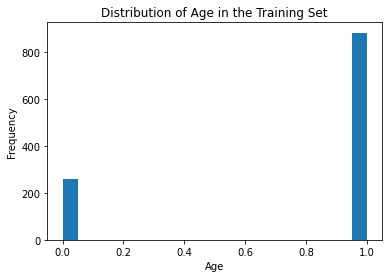

In [10]:
#plot a histogram to show the distribution of age
plt.hist(train_df['married'], bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age in the Training Set')
plt.show()

### Numerical Feature Analysis


NUMERICAL FEATURES ANALYSIS

Numerical Features (73):
['surveyid', 'village', 'femaleres', 'age', 'married', 'children', 'hhsize', 'edu', 'hh_children', 'hh_totalmembers', 'cons_nondurable', 'asset_livestock', 'asset_durable', 'asset_phone', 'asset_savings', 'asset_land_owned_total', 'asset_niceroof', 'cons_allfood', 'cons_ownfood', 'cons_alcohol', 'cons_tobacco', 'cons_med_total', 'cons_med_children', 'cons_ed', 'cons_social', 'cons_other', 'ent_wagelabor', 'ent_ownfarm', 'ent_business', 'ent_nonagbusiness', 'ent_employees', 'ent_nonag_revenue', 'ent_nonag_flowcost', 'ent_farmrevenue', 'ent_farmexpenses', 'ent_animalstockrev', 'ent_total_cost', 'fs_adskipm_often', 'fs_adwholed_often', 'fs_chskipm_often', 'fs_chwholed_often', 'fs_meat', 'fs_enoughtom', 'fs_sleephun', 'med_expenses_hh_ep', 'med_expenses_sp_ep', 'med_expenses_child_ep', 'med_portion_sickinjured', 'med_port_sick_child', 'med_afford_port', 'med_sickdays_hhave', 'med_healthconsult', 'med_vacc_newborns', 'med_child_check', 

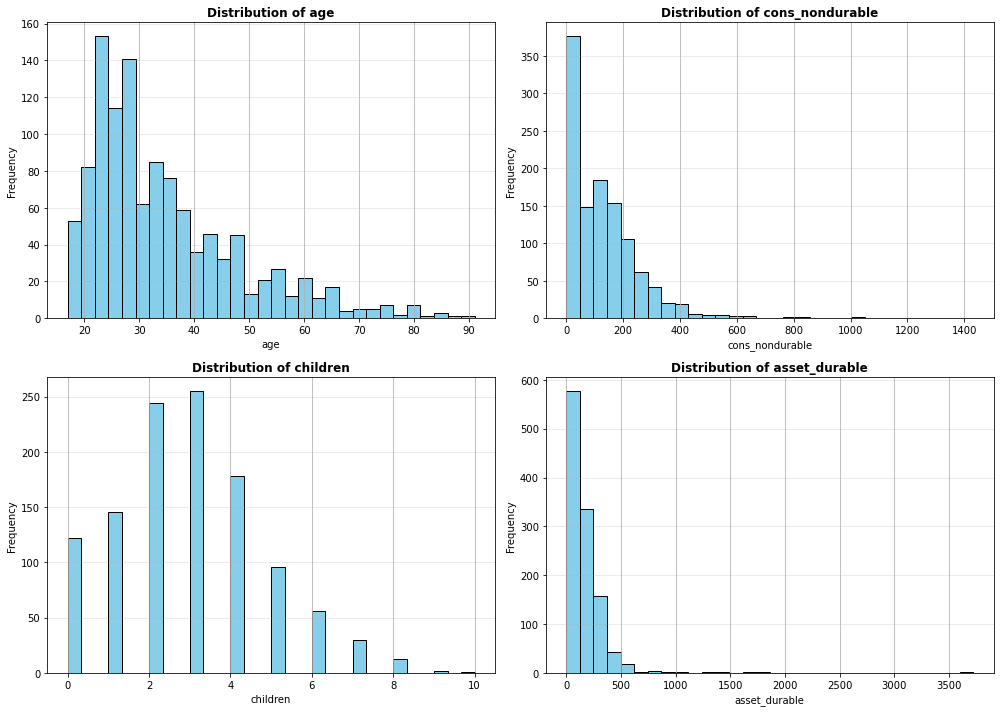

In [11]:
print("\n" + "=" * 60)
print("NUMERICAL FEATURES ANALYSIS")
print("=" * 60)

# Identify numerical columns
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'depressed' in numerical_cols:
    numerical_cols.remove('depressed')

print(f"\nNumerical Features ({len(numerical_cols)}):")
print(numerical_cols)

# Statistical summary
print("\nStatistical Summary:")
print(train_df[numerical_cols].describe())

# Visualize distributions of key numerical features
key_numerical = ['age', 'cons_nondurable', 'children', 'asset_durable']
available_numerical = [col for col in key_numerical if col in train_df.columns]
if available_numerical:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, col in enumerate(available_numerical[:4]):
        train_df[col].hist(bins=30, ax=axes[idx], color='skyblue', edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### Distribution of Categorical Variables

In [12]:
print("\n" + "=" * 60)
print("CATEGORICAL FEATURES ANALYSIS")
print("=" * 60)

# Identify categorical columns
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
if 'surveyid' in categorical_cols:
    categorical_cols.remove('surveyid')

print(f"\nCategorical Features ({len(categorical_cols)}):")
print(categorical_cols)

# Cardinality analysis
print("\nCardinality (Unique Values) for Categorical Features:")
cardinality_df = pd.DataFrame({
    'Feature': categorical_cols,
    'Unique_Values': [train_df[col].nunique() for col in categorical_cols]
}).sort_values('Unique_Values', ascending=False)
print(cardinality_df.to_string(index=False))


CATEGORICAL FEATURES ANALYSIS

Categorical Features (1):
['survey_date']

Cardinality (Unique Values) for Categorical Features:
     Feature  Unique_Values
 survey_date            180


#### Deal with missing values

In [13]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 75 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   surveyid                 286 non-null    int64  
 1   village                  286 non-null    int64  
 2   survey_date              286 non-null    object 
 3   femaleres                286 non-null    int64  
 4   age                      286 non-null    int32  
 5   married                  286 non-null    int64  
 6   children                 286 non-null    int64  
 7   hhsize                   286 non-null    int64  
 8   edu                      286 non-null    int64  
 9   hh_children              286 non-null    int64  
 10  hh_totalmembers          196 non-null    float64
 11  cons_nondurable          286 non-null    float64
 12  asset_livestock          286 non-null    float64
 13  asset_durable            286 non-null    float64
 14  asset_phone              2

In [14]:
binary_cols = []

for col in train_df.columns:
    if col in test_df.columns:
        train_vals = set(train_df[col].dropna().unique())
        test_vals = set(test_df[col].dropna().unique())
        
        if train_vals.issubset({0,1}) and test_vals.issubset({0,1}):
            binary_cols.append(col)

print(binary_cols)

['femaleres', 'married', 'asset_niceroof', 'ent_wagelabor', 'ent_ownfarm', 'ent_business', 'ent_nonagbusiness', 'fs_enoughtom', 'fs_sleephun', 'med_vacc_newborns', 'med_child_check', 'labor_primary', 'given_mpesa', 'received_mpesa', 'saved_mpesa', 'early_survey', 'depressed']


In [15]:
# Fill missing values with 2
train_df[binary_cols] = train_df[binary_cols].fillna(2)

# Make sure test has same columns before applying
common_binary_cols = [col for col in binary_cols if col in test_df.columns]

test_df[common_binary_cols] = test_df[common_binary_cols].fillna(2)

In [16]:
other_cols = [col for col in train_df.columns if col not in binary_cols]

train_df[other_cols] = train_df[other_cols].fillna(0)

In [17]:
other_cols = [col for col in test_df.columns if col not in binary_cols]

test_df[other_cols] = test_df[other_cols].fillna(0)

In [18]:
#drop columns; surveyid,village,survey date,med_vacc_newborns, med_child_check  
#train_df.drop(columns=['surveyid','village','survey_date','med_vacc_newborns','med_child_check'],inplace= True)

#drop also in test_df
#test_df.drop(columns=['surveyid','village','survey_date','med_vacc_newborns','med_child_check'],inplace= True)


In [19]:
train_df['age'] = train_df['age'].astype(int)

In [20]:
train_df.head()

,surveyid,village,survey_date,femaleres,age,married,children,hhsize,edu,hh_children,...,given_mpesa,amount_given_mpesa,received_mpesa,amount_received_mpesa,net_mpesa,saved_mpesa,amount_saved_mpesa,early_survey,depressed,day_of_week
0,926,91,23-Nov-61,1,28,1,4,6,10,0,...,0,0.0,0,0.000000,0.000000,1,0.000000,0,0,5
1,747,57,24-Oct-61,1,23,1,3,5,8,0,...,0,0.0,1,4.804611,4.804611,0,0.000000,0,1,3
2,1190,115,05-Oct-61,1,22,1,3,5,9,0,...,0,0.0,0,8.007685,8.007685,1,0.000000,0,0,5
3,1065,97,23-Sep-61,1,27,1,2,4,10,2,...,0,0.0,0,0.000000,0.000000,1,1.249199,0,0,0
4,806,42,12-Sep-61,0,59,0,4,6,10,4,...,0,0.0,0,0.000000,0.000000,0,0.000000,0,0,3


In [21]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 75 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   surveyid                 1143 non-null   int64  
 1   village                  1143 non-null   int64  
 2   survey_date              1143 non-null   object 
 3   femaleres                1143 non-null   int64  
 4   age                      1143 non-null   int32  
 5   married                  1143 non-null   int64  
 6   children                 1143 non-null   int64  
 7   hhsize                   1143 non-null   int64  
 8   edu                      1143 non-null   int64  
 9   hh_children              1143 non-null   int64  
 10  hh_totalmembers          1143 non-null   float64
 11  cons_nondurable          1143 non-null   float64
 12  asset_livestock          1143 non-null   float64
 13  asset_durable            1143 non-null   float64
 14  asset_phone             

In [22]:
test_only = set(test_df.columns) - set(train_df.columns)
print("Test only columns:", test_only)

Test only columns: set()


In [23]:
#Convert USD in money cols to KES
usd_to_kes = 129.65 

money_cols = [
    'cons_allfood', 'cons_ownfood', 'cons_alcohol', 'cons_tobacco',
    'cons_med_total', 'cons_med_children', 'cons_ed', 'cons_social', 'cons_other',
    'cons_nondurable','asset_livestock', 'asset_durable', 'asset_phone', 'asset_savings',
    'asset_land_owned_total','ent_nonag_revenue','ent_nonag_flowcost','ent_farmrevenue','ent_farmexpenses','ent_animalstockrev','ent_total_cost',
    'med_expenses_hh_ep','med_expenses_sp_ep','med_expenses_child_ep','ed_expenses','ed_expenses_perkid'

]

In [24]:
train_df[money_cols] = train_df[money_cols] * usd_to_kes
test_df[money_cols] = test_df[money_cols] * usd_to_kes

In [25]:
train_df.drop(columns='survey_date', axis=1)


,surveyid,village,femaleres,age,married,children,hhsize,edu,hh_children,hh_totalmembers,...,given_mpesa,amount_given_mpesa,received_mpesa,amount_received_mpesa,net_mpesa,saved_mpesa,amount_saved_mpesa,early_survey,depressed,day_of_week
0,926,91,1,28,1,4,6,10,0,0.0,...,0,0.0,0,0.000000,0.000000,1,0.000000,0,0,5
1,747,57,1,23,1,3,5,8,0,0.0,...,0,0.0,1,4.804611,4.804611,0,0.000000,0,1,3
2,1190,115,1,22,1,3,5,9,0,0.0,...,0,0.0,0,8.007685,8.007685,1,0.000000,0,0,5
3,1065,97,1,27,1,2,4,10,2,4.0,...,0,0.0,0,0.000000,0.000000,1,1.249199,0,0,0
4,806,42,0,59,0,4,6,10,4,6.0,...,0,0.0,0,0.000000,0.000000,0,0.000000,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,927,152,1,36,0,4,5,9,0,0.0,...,0,0.0,0,0.000000,0.000000,0,0.000000,0,1,4
1139,1039,104,1,23,1,0,2,10,0,2.0,...,0,0.0,0,0.000000,0.000000,1,0.000000,0,0,4
1140,428,54,1,28,1,5,7,10,5,7.0,...,0,0.0,0,0.000000,0.000000,0,0.000000,0,0,5
1141,23,3,1,33,0,4,5,9,0,0.0,...,0,0.0,0,0.000000,0.000000,0,0.000000,0,0,5


In [26]:
numeric_df = train_df.select_dtypes(include=['number'])

corr_with_target = numeric_df.corr()['depressed'].sort_values(ascending=False)

print(corr_with_target)

depressed             1.000000
fs_adwholed_often     0.143458
age                   0.100068
med_expenses_sp_ep    0.074052
fs_chwholed_often     0.070507
                        ...   
asset_durable        -0.047191
married              -0.078541
edu                  -0.122236
med_vacc_newborns          NaN
med_child_check            NaN
Name: depressed, Length: 74, dtype: float64


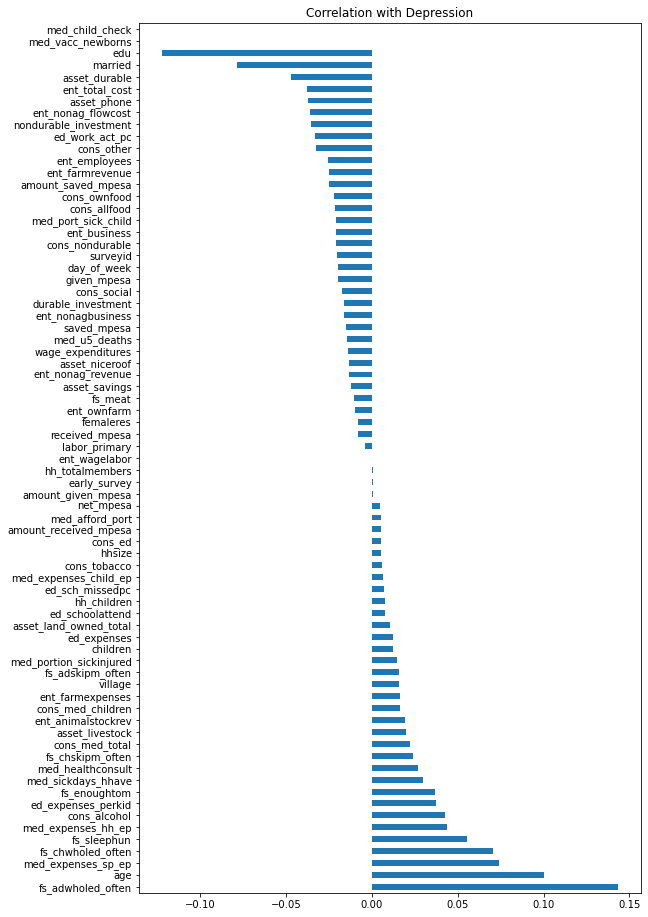

In [27]:
plt.figure(figsize=(9, 16))
corr_with_target.drop('depressed').plot(kind='barh')
plt.title('Correlation with Depression')
plt.show()

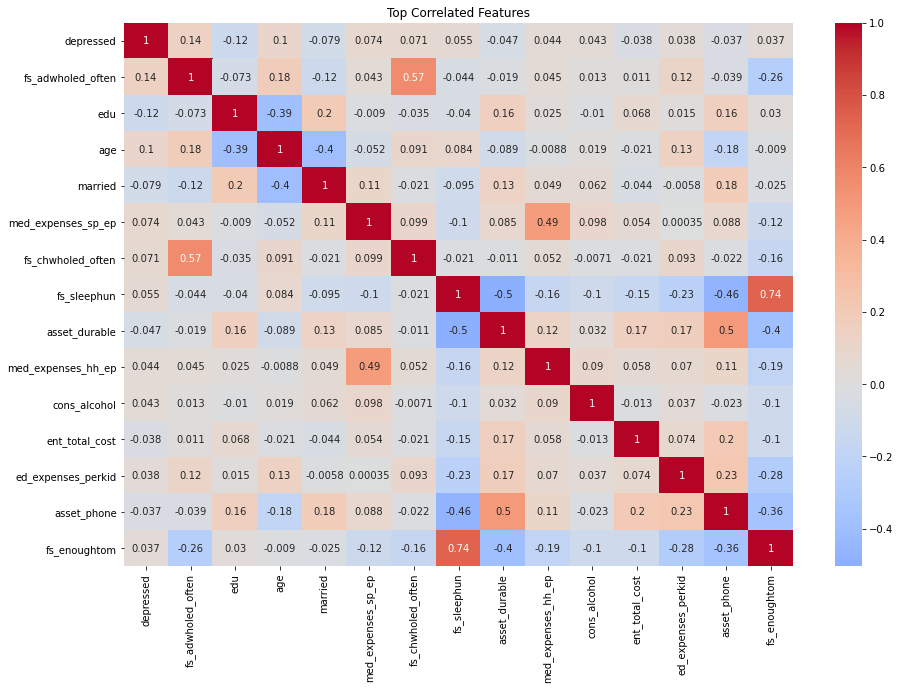

In [28]:
top_features = corr_with_target.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(15, 10))
sns.heatmap(train_df[top_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Top Correlated Features')
plt.show()

In [29]:
# Top positive correlations
print("Top positive correlations:")
print(corr_with_target.sort_values(ascending=False).head(10))

# Top negative correlations
print("\nTop negative correlations:")
print(corr_with_target.sort_values().head(10))

Top positive correlations:
depressed             1.000000
fs_adwholed_often     0.143458
age                   0.100068
med_expenses_sp_ep    0.074052
fs_chwholed_often     0.070507
fs_sleephun           0.055357
med_expenses_hh_ep    0.043688
cons_alcohol          0.042513
ed_expenses_perkid    0.037558
fs_enoughtom          0.036832
Name: depressed, dtype: float64

Top negative correlations:
edu                     -0.122236
married                 -0.078541
asset_durable           -0.047191
ent_total_cost          -0.037660
asset_phone             -0.037200
ent_nonag_flowcost      -0.035660
nondurable_investment   -0.035176
ed_work_act_pc          -0.032992
cons_other              -0.032684
ent_employees           -0.025294
Name: depressed, dtype: float64


### Analyse the depressed class' trends

In [30]:
depressed = train_df[train_df['depressed'] == 1]
depressed

,surveyid,village,survey_date,femaleres,age,married,children,hhsize,edu,hh_children,...,given_mpesa,amount_given_mpesa,received_mpesa,amount_received_mpesa,net_mpesa,saved_mpesa,amount_saved_mpesa,early_survey,depressed,day_of_week
1,747,57,24-Oct-61,1,23,1,3,5,8,0,...,0,0.0,1,4.804611,4.804611,0,0.0,0,1,3
6,849,130,31-Oct-61,0,34,0,1,3,9,1,...,0,0.0,0,0.000000,0.000000,0,0.0,0,1,3
10,540,52,26-Oct-61,1,84,0,0,1,1,0,...,0,0.0,0,0.000000,0.000000,0,0.0,0,1,5
14,603,100,21-Sep-60,1,56,1,0,2,12,0,...,0,0.0,0,0.000000,0.000000,0,0.0,1,1,4
20,1001,207,28-Nov-61,1,40,0,0,2,7,0,...,0,0.0,0,0.000000,0.000000,0,0.0,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1104,393,31,20-Nov-61,1,66,0,0,1,1,0,...,0,0.0,0,0.000000,0.000000,0,0.0,0,1,2
1107,167,12,24-Oct-61,1,23,0,3,4,10,0,...,0,0.0,0,0.000000,0.000000,0,0.0,0,1,3
1116,447,25,18-Oct-61,1,35,1,2,4,10,2,...,0,0.0,0,0.000000,0.000000,0,0.0,0,1,4
1138,927,152,27-Dec-61,1,36,0,4,5,9,0,...,0,0.0,0,0.000000,0.000000,0,0.0,0,1,4


In [31]:
#distribution of femelares in depressed 
depressed['femaleres'].value_counts()

1    176
0     17
Name: femaleres, dtype: int64

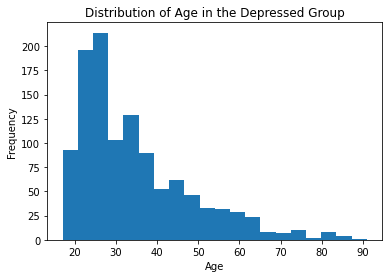

In [32]:
plt.hist(train_df['age'], bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age in the Depressed Group');


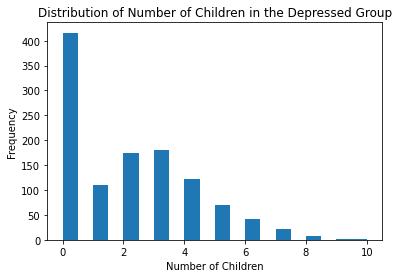

In [33]:
plt.hist(train_df['hh_children'], bins=20)
plt.xlabel('Number of Children')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Children in the Depressed Group');


In [34]:
print(depressed['ent_wagelabor'].value_counts())
print(depressed['ent_ownfarm'].value_counts())
print(depressed['ent_business'].value_counts())
print(depressed['ent_employees'].value_counts())

0    157
1     36
Name: ent_wagelabor, dtype: int64
0    147
1     46
Name: ent_ownfarm, dtype: int64
0    175
1     18
Name: ent_business, dtype: int64
0    191
1      2
Name: ent_employees, dtype: int64


In [35]:
depressed['hhsize'].describe()

count    193.000000
mean       4.896373
std        2.169782
min        1.000000
25%        4.000000
50%        5.000000
75%        6.000000
max       12.000000
Name: hhsize, dtype: float64

In [36]:
depressed['saved_mpesa'].value_counts()

0    159
1     34
Name: saved_mpesa, dtype: int64

### Value of assets

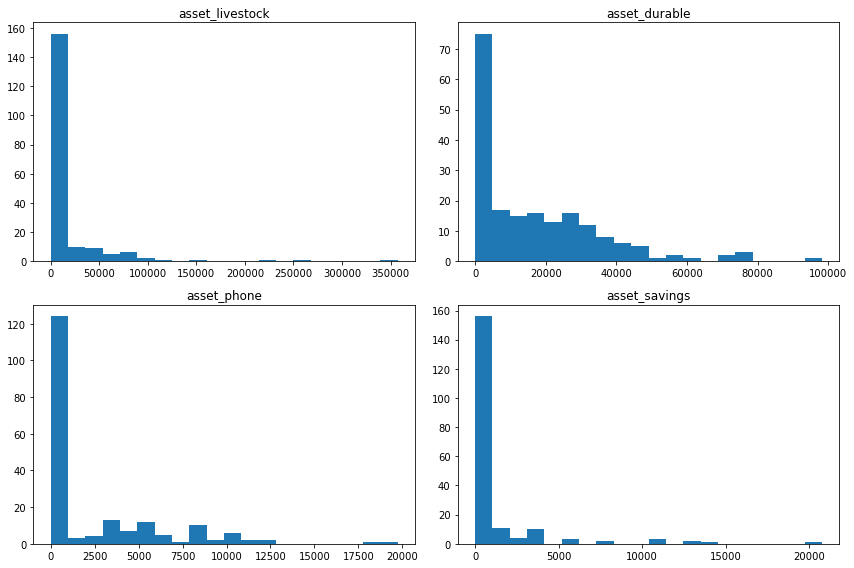

In [37]:
cols = ['asset_livestock', 'asset_durable', 'asset_phone', 'asset_savings']

plt.figure(figsize=(12, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(depressed[col], bins=20)
    plt.title(col)

plt.tight_layout()
plt.show()

### Expenditure on food

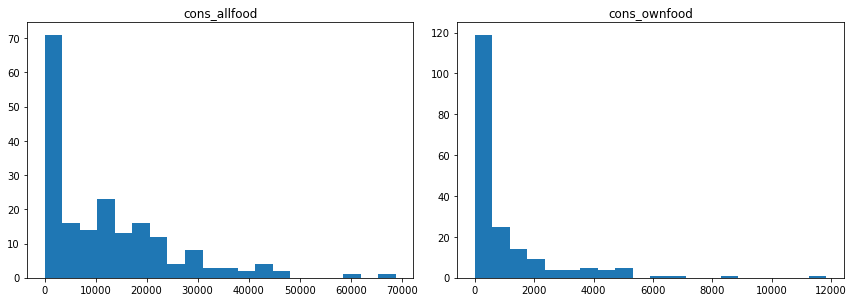

In [38]:
cols = ['cons_allfood', 'cons_ownfood']

plt.figure(figsize=(12, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(depressed[col], bins=20)
    plt.title(col)

plt.tight_layout()
plt.show()

### Expenditure on drugs

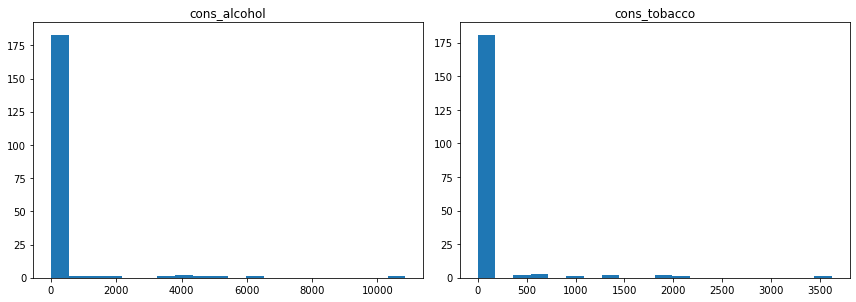

In [39]:
cols = ['cons_alcohol', 'cons_tobacco']

plt.figure(figsize=(12, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(depressed[col], bins=20)
    plt.title(col)

plt.tight_layout()
plt.show()

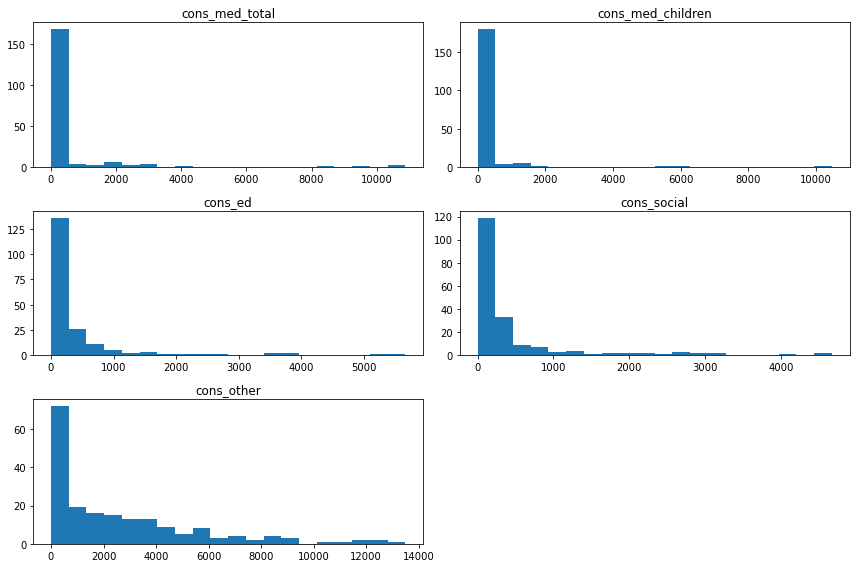

In [40]:
cols = ['cons_med_total', 'cons_med_children','cons_ed','cons_social', 'cons_other']

plt.figure(figsize=(12, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 2, i)
    plt.hist(depressed[col], bins=20)
    plt.title(col)

plt.tight_layout()
plt.show()

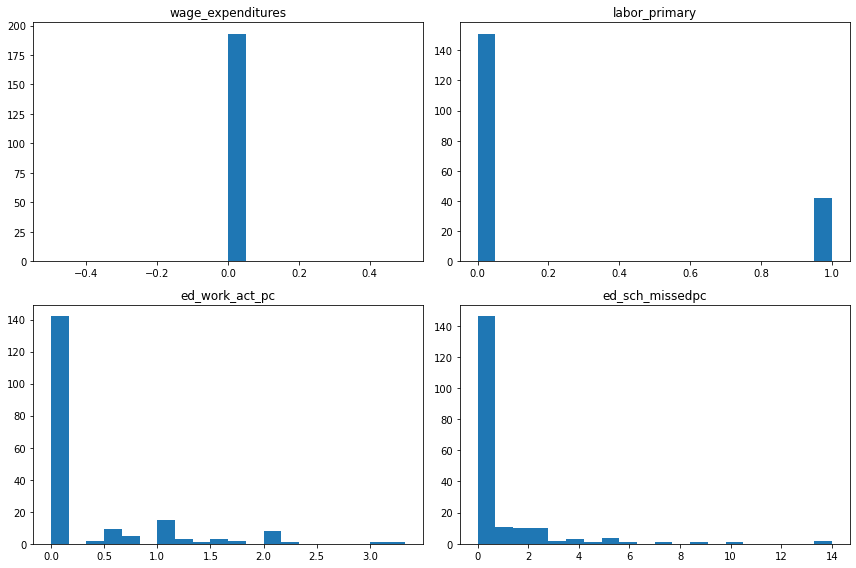

In [41]:
cols = ['wage_expenditures', 'labor_primary', 'ed_work_act_pc','ed_sch_missedpc']

plt.figure(figsize=(12, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(depressed[col], bins=20)
    plt.title(col)

plt.tight_layout()
plt.show()

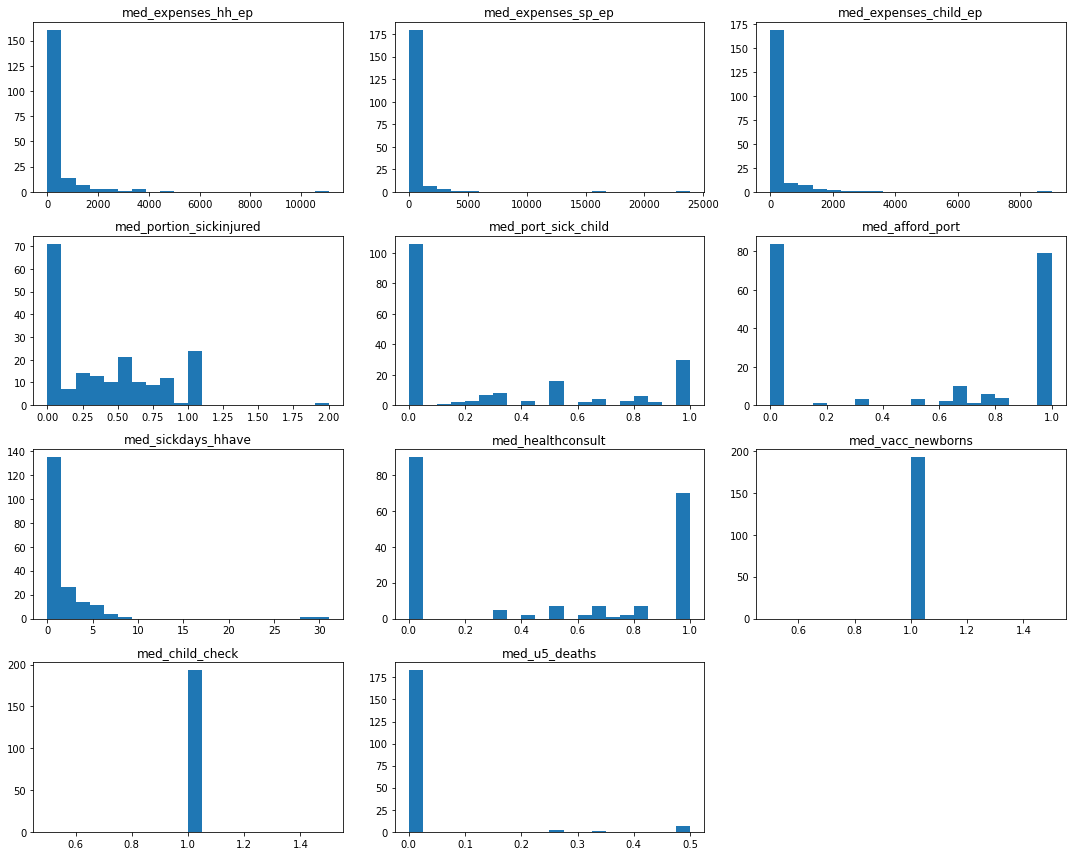

In [42]:


medical_cols = [
    'med_expenses_hh_ep',
    'med_expenses_sp_ep',
    'med_expenses_child_ep',
    'med_portion_sickinjured',
    'med_port_sick_child',
    'med_afford_port',
    'med_sickdays_hhave',
    'med_healthconsult',
    'med_vacc_newborns',
    'med_child_check',
    'med_u5_deaths'
]

plt.figure(figsize=(15, 12))

for i, col in enumerate(medical_cols, 1):
    plt.subplot(4, 3, i)  # 4 rows, 3 columns
    plt.hist(depressed[col], bins=20)
    plt.title(col)
    
plt.tight_layout()
plt.show()

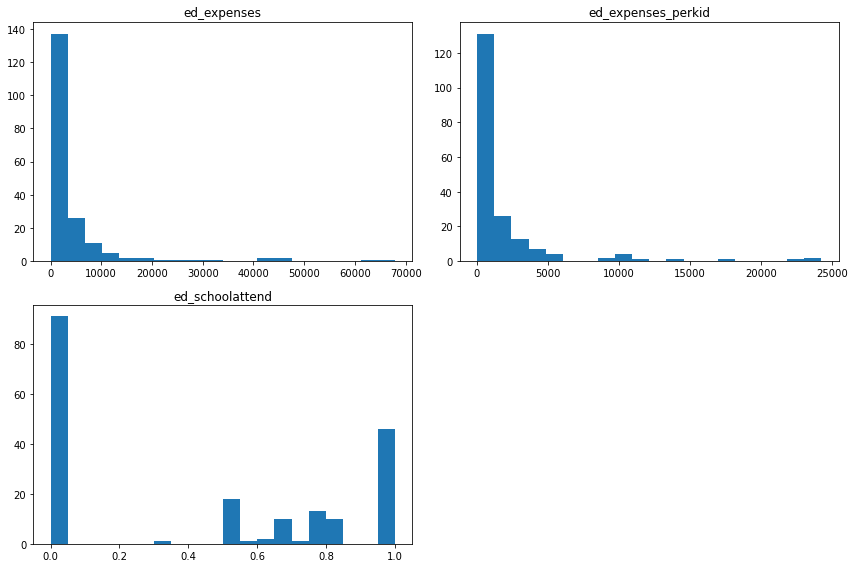

In [43]:
cols = ['ed_expenses', 'ed_expenses_perkid', 'ed_schoolattend']

plt.figure(figsize=(12, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(depressed[col], bins=20)
    plt.title(col)

plt.tight_layout()
plt.show()


NUMERICAL FEATURES ANALYSIS

Numerical Features (72):
['surveyid', 'village', 'femaleres', 'married', 'children', 'hhsize', 'edu', 'hh_children', 'hh_totalmembers', 'cons_nondurable', 'asset_livestock', 'asset_durable', 'asset_phone', 'asset_savings', 'asset_land_owned_total', 'asset_niceroof', 'cons_allfood', 'cons_ownfood', 'cons_alcohol', 'cons_tobacco', 'cons_med_total', 'cons_med_children', 'cons_ed', 'cons_social', 'cons_other', 'ent_wagelabor', 'ent_ownfarm', 'ent_business', 'ent_nonagbusiness', 'ent_employees', 'ent_nonag_revenue', 'ent_nonag_flowcost', 'ent_farmrevenue', 'ent_farmexpenses', 'ent_animalstockrev', 'ent_total_cost', 'fs_adskipm_often', 'fs_adwholed_often', 'fs_chskipm_often', 'fs_chwholed_often', 'fs_meat', 'fs_enoughtom', 'fs_sleephun', 'med_expenses_hh_ep', 'med_expenses_sp_ep', 'med_expenses_child_ep', 'med_portion_sickinjured', 'med_port_sick_child', 'med_afford_port', 'med_sickdays_hhave', 'med_healthconsult', 'med_vacc_newborns', 'med_child_check', 'med_u5

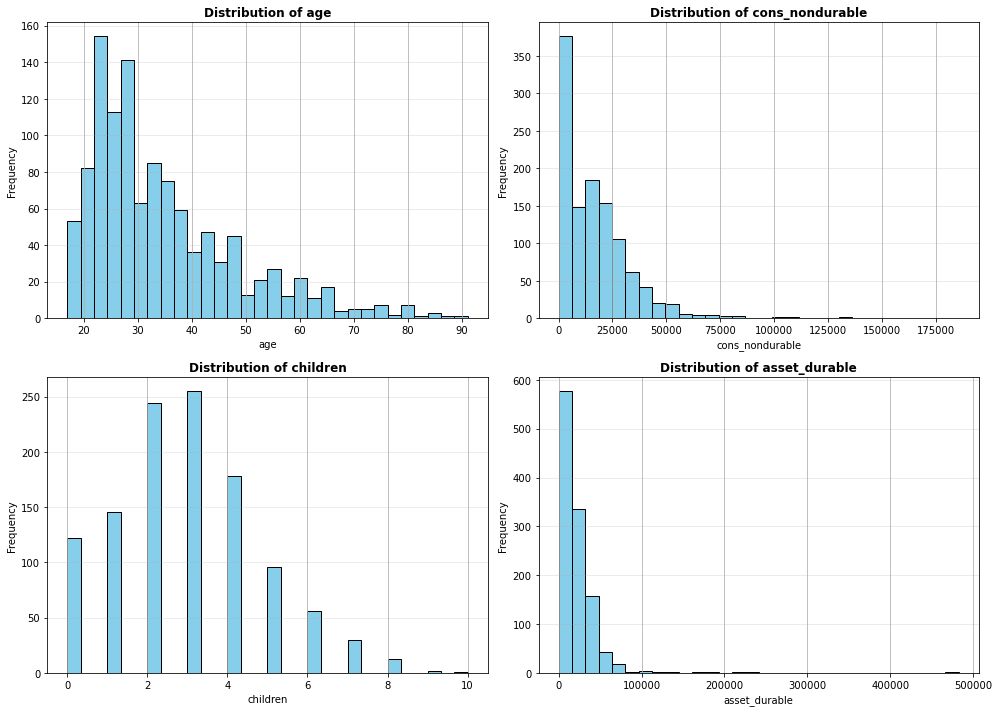

In [44]:
print("\n" + "=" * 60)
print("NUMERICAL FEATURES ANALYSIS")
print("=" * 60)

# Identify numerical columns
numerical_cols = depressed.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'depressed' in numerical_cols:
    numerical_cols.remove('depressed')

print(f"\nNumerical Features ({len(numerical_cols)}):")
print(numerical_cols)

# Statistical summary
print("\nStatistical Summary:")
print(train_df[numerical_cols].describe())

# Visualize distributions of key numerical features
key_numerical = ['age', 'cons_nondurable', 'children', 'asset_durable']
available_numerical = [col for col in key_numerical if col in train_df.columns]
if available_numerical:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, col in enumerate(available_numerical[:4]):
        train_df[col].hist(bins=30, ax=axes[idx], color='skyblue', edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### FEATURE ENGINEERING

In [60]:
from sklearn.decomposition import PCA

# 1. Select the relevant columns
food_cols = ['fs_adwholed_often', 'fs_chwholed_often', 'fs_sleephun', 'fs_enoughtom']

# 2. IMPORTANT: You must Scale/Standardize first
# PCA is sensitive to the scale of data. This puts binary (0/1) 
# and continuous (0-30) on a comparable mean/variance level.
scaler = StandardScaler()
food_scaled = scaler.fit_transform(train_df[food_cols])

# 3. Apply PCA
# We want 'n_components=1' because we want to collapse 4 columns into 1 Index
pca = PCA(n_components=1)
train_df['food_insecurity_index'] = pca.fit_transform(food_scaled)
test_df['food_insecurity_index'] = pca.transform(scaler.transform(test_df[food_cols]))
# 4. Check the "Weights" (Optional but useful)
print("Importance of each feature in the index:")
print(dict(zip(food_cols, pca.components_[0])))

Importance of each feature in the index:
{'fs_adwholed_often': 0.4429205511202886, 'fs_chwholed_often': 0.3936954912728306, 'fs_sleephun': -0.5225429737047232, 'fs_enoughtom': -0.6130041485818588}


In [61]:
X = train_df.drop(columns=['depressed', 'surveyid','survey_date'])
y = train_df['depressed']



X_test = test_df.drop(columns=['depressed', 'surveyid', 'survey_date'])

In [47]:
#X_train, X_val, y_train, y_val = train_test_split(
    #X, y, test_size=0.2, random_state=42, stratify= y
#)

### Fit Baseline Model

In [62]:
#create the model
model = LogisticRegression(solver='liblinear',random_state=42)

#train the model
model.fit(X, y)

c:\Users\user\anaconda3\envs\learn-env\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LogisticRegression(random_state=42, solver='liblinear')

In [63]:
# get the classes of the model
model.classes_

array([0, 1], dtype=int64)

#### Evaluate the model

Check the perfomance of the model with .predict_proba() which returns a matrix of probabiliites that the predicted output is equal or close to zero.


In [64]:
model.intercept_

array([-0.00352327])

In [65]:
model.predict_proba(X)

array([[0.79394   , 0.20606   ],
       [0.73922862, 0.26077138],
       [0.77726648, 0.22273352],
       ...,
       [0.95564171, 0.04435829],
       [0.75631047, 0.24368953],
       [0.90426892, 0.09573108]])

In [66]:
model.predict(X)

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [67]:
train_df['depressed'].value_counts()

# 1 for Yes and 0 for No

0    950
1    193
Name: depressed, dtype: int64

In [68]:
model.score(X, y)

0.8320209973753281

Confusion matrix to show the actual and predicted outputs

In [69]:
confusion_matrix(y, model.predict(X))


array([[947,   3],
       [189,   4]], dtype=int64)

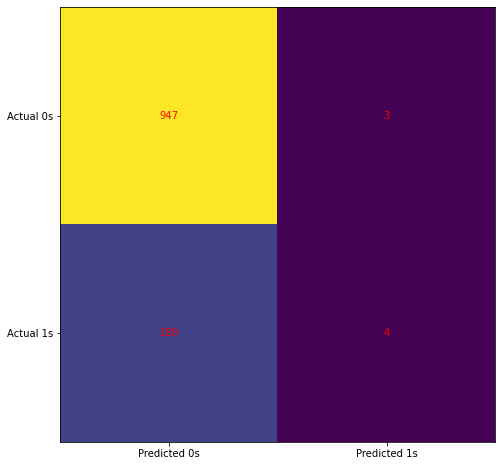

In [70]:
cm = confusion_matrix(y, model.predict(X))

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(cm)
ax.grid(False)
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='red')
plt.show()

In [71]:
#Print Classification Report
print(classification_report(y, model.predict(X)))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91       950
           1       0.57      0.02      0.04       193

    accuracy                           0.83      1143
   macro avg       0.70      0.51      0.47      1143
weighted avg       0.79      0.83      0.76      1143



In [72]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 76 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   surveyid                 286 non-null    int64  
 1   village                  286 non-null    int64  
 2   survey_date              286 non-null    object 
 3   femaleres                286 non-null    int64  
 4   age                      286 non-null    int32  
 5   married                  286 non-null    int64  
 6   children                 286 non-null    int64  
 7   hhsize                   286 non-null    int64  
 8   edu                      286 non-null    int64  
 9   hh_children              286 non-null    int64  
 10  hh_totalmembers          286 non-null    float64
 11  cons_nondurable          286 non-null    float64
 12  asset_livestock          286 non-null    float64
 13  asset_durable            286 non-null    float64
 14  asset_phone              2

In [73]:
predictions = model.predict(X_test)
predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64)

In [74]:
p = pd.DataFrame({
    "surveyid": test_df["surveyid"],
    "depressed": predictions
})


p.head(20)

,surveyid,depressed
0,901,0
1,498,0
2,710,0
3,433,0
4,44,0
5,172,0
6,1342,0
7,228,0
8,1421,0
9,977,0


In [ ]:
# save p to csv file
p.to_csv('predictions1.csv', index=False)

### Add improvements to te model


In [75]:
train_df['depressed'].value_counts()

0    950
1    193
Name: depressed, dtype: int64

In [76]:
model1 = LogisticRegression(solver='liblinear', C=10.0,class_weight= 'balanced', random_state=0)
model1.fit(X, y)

c:\Users\user\anaconda3\envs\learn-env\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LogisticRegression(C=10.0, class_weight='balanced', random_state=0,
                   solver='liblinear')

In [77]:
model1.intercept_

array([-0.00129817])

In [78]:
model1.score(X, y)

0.6614173228346457

Split the data 

In [79]:
X_train, X_val, y_train, y_val =\
    train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Standardization

### Tune the model

### SMOTE

In [80]:
# Previous original class distribution
print(y_train.value_counts())

print(y_val.value_counts())

# Fit SMOTE to training data
smote=SMOTE()
X_train_resampled, y_train_resampled = smote.fit_resample(X_train,y_train)

# Preview synthetic sample class distribution
print('\n')
print(pd.Series(y_train_resampled).value_counts()) 

0    760
1    154
Name: depressed, dtype: int64
0    190
1     39
Name: depressed, dtype: int64


1    760
0    760
Name: depressed, dtype: int64


In [81]:
scaler = StandardScaler()
X_train_transformed = scaler.fit_transform(X_train_resampled)
X_val_transformed = scaler.transform(X_val)

Build models with resampled training data

LogisticRegression(C=0.005, fit_intercept=False, max_iter=1000,
                   solver='liblinear')
AUC for 0.005: 0.5456140350877192
-------------------------------------------------------------------------------------
LogisticRegression(C=0.1, fit_intercept=False, max_iter=1000,
                   solver='liblinear')
AUC for 0.1: 0.5491228070175439
-------------------------------------------------------------------------------------
LogisticRegression(C=0.2, fit_intercept=False, max_iter=1000,
                   solver='liblinear')
AUC for 0.2: 0.5516869095816463
-------------------------------------------------------------------------------------
LogisticRegression(C=0.5, fit_intercept=False, max_iter=1000,
                   solver='liblinear')
AUC for 0.5: 0.5527665317139001
-------------------------------------------------------------------------------------
LogisticRegression(C=0.8, fit_intercept=False, max_iter=1000,
                   solver='liblinear')
AUC for 0.8: 0.5543

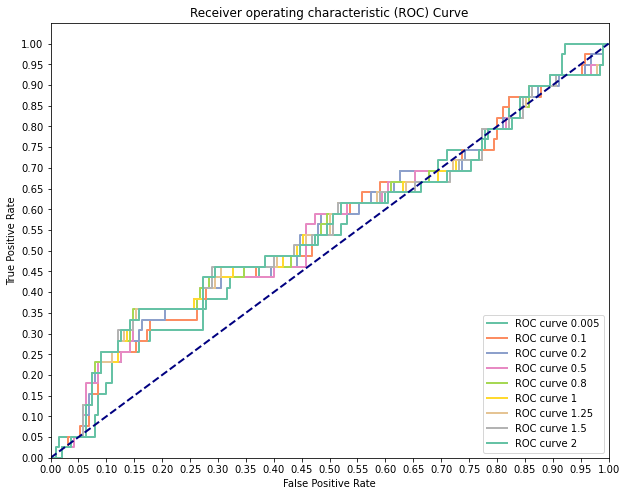

In [82]:
# Now let's compare a few different regularization performances on the dataset
C_param_range = [0.005, 0.1, 0.2, 0.5, 0.8, 1, 1.25, 1.5, 2]
names = [0.005, 0.1, 0.2, 0.5, 0.8, 1, 1.25, 1.5, 2]
colors = sns.color_palette('Set2', n_colors=len(names))

plt.figure(figsize=(10, 8))

# Write a for loop that builds models for each value of C_param_range, prints the AUC and plots the ROC
for n,c in enumerate(C_param_range):
    #fit the model
    logreg= LogisticRegression(fit_intercept= False,  C=c, solver='liblinear',max_iter=1000)  #instantiate the model
    model_log= logreg.fit(X_train_transformed,y_train_resampled)
    print(model_log)
    
    
    #predict
    
    y_pred= logreg.predict(X_val_transformed)
    
    y_score= logreg.decision_function(X_val_transformed)
    
    fpr,tpr,thresholds= roc_curve(y_val,y_score)
    
    print('AUC for {}: {}'.format(names[n], auc(fpr, tpr)))
    print('-------------------------------------------------------------------------------------')
    lw = 2
    plt.plot(fpr, tpr, color=colors[n],
             lw=lw, label='ROC curve {}'.format(names[n]))



plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.yticks([i/20.0 for i in range(21)])
plt.xticks([i/20.0 for i in range(21)])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [83]:
#get the model score
score = logreg.score(X_val_transformed, y_val)
print(f"Accuracy for {names[n]}: {score}")


Accuracy for 2: 0.7205240174672489


## Run a Random Forest Model on the data

In [89]:
tree_clf = DecisionTreeClassifier(criterion = 'gini', random_state=42, max_depth=5)
tree_clf.fit(X_train_transformed, y_train_resampled)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [90]:
tree_clf.feature_importances_

array([0.        , 0.        , 0.02666989, 0.17990806, 0.        ,
       0.01150887, 0.04188062, 0.        , 0.02284849, 0.        ,
       0.01534859, 0.        , 0.00205085, 0.02576879, 0.0031422 ,
       0.        , 0.        , 0.        , 0.05122931, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.04154184, 0.08071317, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.04279331, 0.        , 0.        ,
       0.027062  , 0.        , 0.        , 0.        , 0.1200016 ,
       0.        , 0.08518349, 0.        , 0.05771501, 0.        ,
       0.01499686, 0.        , 0.        , 0.01762756, 0.        ,
       0.        , 0.04531542, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.03405493, 0.05263915, 0.        ])

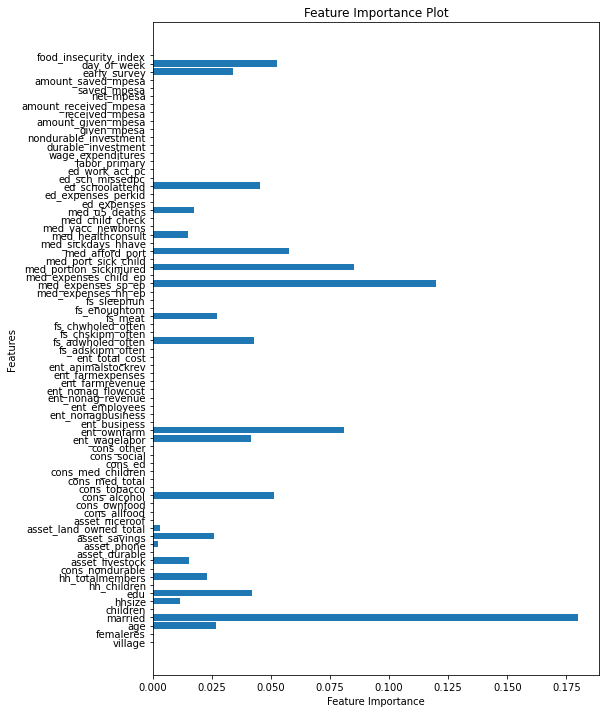

In [96]:

#Feature importance
def plot_feature_importances(model):
    n_features = X_train.shape[1]
    plt.figure(figsize= (8,12))
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), X_train.columns.values)
    plt.xlabel('Feature Importance')
    plt.ylabel('Features')
    plt.title('Feature Importance Plot')
    plt.show()

plot_feature_importances(tree_clf)

#### Model Performance

In [98]:
# Test set Prediction
pred = tree_clf.predict(X_val_transformed)

#Confusion matrix and classification report
print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred))

[[160  30]
 [ 30   9]]
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       190
           1       0.23      0.23      0.23        39

    accuracy                           0.74       229
   macro avg       0.54      0.54      0.54       229
weighted avg       0.74      0.74      0.74       229



In [99]:
print("Testing Accuracy for Decision Tree Classifier: {:.4}%".format(accuracy_score(y_val,pred)* 100))

Testing Accuracy for Decision Tree Classifier: 73.8%


### Bagged Trees

In [100]:
#Instatiate a Bagging Classifier
bagged_tree = BaggingClassifier(DecisionTreeClassifier(criterion = 'gini', max_depth = 5), n_estimators = 20)

In [101]:
# Fit the training data
bagged_tree.fit(X_train_transformed, y_train_resampled)

BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5),
                  n_estimators=20)

In [102]:
# Training accuracy score
bagged_tree.score(X_train_transformed, y_train_resampled)

0.875

In [103]:
#Test Accuracy score
bagged_tree.score(X_val_transformed, y_val)

0.759825327510917

The model is overfitting

### Random Forests